SISTECH 2026 — MLOps Hands-On 1
## Membangun Fondasi Sistem Prediksi **Risk Score** (Chicago Crimes)

**Alur:**
1. Setup & load dataset (Chicago Crimes)
2. Pembersihan data
3. **EDA** — memahami pola kejahatan lintas *waktu* dan *lokasi*
4. **Feature Engineering** — temporal (cyclical encoding) & spasial (grid aggregation)
5. **Pseudo-Labeling** — severity scoring + temporal decay + agregasi spasial → Risk Score
6. Menyusun & menyimpan dataset akhir (CSV/Parquet)

---

# 0. Installation & Setup

In [43]:
import sys
print(sys.executable)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
print("Setup selesai ✅")

c:\Users\User\github_project\Smart-Protection-Platform-SISTECH2026\venv\Scripts\python.exe
Setup selesai ✅


# 1. Download & Import Dataset

Kita memakai dataset **Chicago Crimes**. Kolom-kolom penting untuk kita:
`Date`, `Primary Type`, `Description`, `Latitude`, `Longitude`, `Arrest`, `Location Description`.

In [44]:
import pandas as pd

usecols = [
    "ID", "Date", "Primary Type", "Description",
    "Location Description", "Arrest",
    "Latitude", "Longitude", "Year"
]

df = pd.read_csv(
    "../data/dataset/chicago_crimes.csv",
    usecols=usecols
)

print("Shape mentah:", df.shape)
df.head()

Shape mentah: (8534663, 9)


,ID,Date,Primary Type,Description,Location Description,Arrest,Year,Latitude,Longitude
0,14165870,04/11/2026 12:00:00 AM,THEFT,$500 AND UNDER,STREET,False,2026,41.801025,-87.652621
1,14170655,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT $300 AND UNDER,RESIDENCE,False,2026,NaN,NaN
2,14164088,04/11/2026 12:00:00 AM,BATTERY,SIMPLE,STREET,False,2026,41.884097,-87.675228
3,14163678,04/11/2026 12:00:00 AM,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,APARTMENT,True,2026,41.977655,-87.697553
4,14164937,04/11/2026 12:00:00 AM,THEFT,THEFT FROM MOTOR VEHICLE,GAS STATION,False,2026,41.954538,-87.651148


In [45]:
if "Year" in df.columns:
    last_year = int(df["Year"].max())
    df = df[df["Year"] >= last_year - 2].copy()
    print(f"Subset {last_year-2}-{last_year}. Shape:", df.shape)

Subset 2024-2026. Shape: (553919, 9)


# 2. Pembersihan Data

- **Parse kolom `Date`** menjadi tipe datetime (format Chicago: `MM/DD/YYYY HH:MM:SS AM/PM`).
- **Buang baris tanpa koordinat / tanggal** — tanpa `Latitude`/`Longitude`, sebuah kejadian
  tidak bisa dipetakan ke grid spasial.
- **Filter koordinat di luar bounding box Chicago** (menyingkirkan koordinat rusak / 0,0).
- Turunkan kolom waktu dasar: `hour`, `dow` (day-of-week), `month`.

In [46]:
# Parse tanggal
df["Datetime"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")

before = len(df)
# Buang baris tanpa koordinat / tanpa tanggal valid
df = df.dropna(subset=["Latitude", "Longitude", "Datetime"]).copy()

# Bounding box kasar wilayah Chicago -> singkirkan koordinat rusak
df = df[df["Latitude"].between(41.60, 42.05) &
        df["Longitude"].between(-87.95, -87.50)].copy()

# Fitur waktu dasar
df["hour"]  = df["Datetime"].dt.hour
df["dow"]   = df["Datetime"].dt.dayofweek        # 0 = Senin ... 6 = Minggu
df["month"] = df["Datetime"].dt.month

print(f"Dibuang {before - len(df):,} baris. Shape bersih: {df.shape}")
df[["Datetime", "Primary Type", "Description", "Latitude", "Longitude", "hour", "dow"]].head()

Dibuang 3,023 baris. Shape bersih: (550896, 13)


,Datetime,Primary Type,Description,Latitude,Longitude,hour,dow
0,2026-04-11,THEFT,$500 AND UNDER,41.801025,-87.652621,0,5
2,2026-04-11,BATTERY,SIMPLE,41.884097,-87.675228,0,5
3,2026-04-11,DECEPTIVE PRACTICE,THEFT OF LOST / MISLAID PROPERTY,41.977655,-87.697553,0,5
4,2026-04-11,THEFT,THEFT FROM MOTOR VEHICLE,41.954538,-87.651148,0,5
5,2026-04-11,BATTERY,SIMPLE,41.951894,-87.747276,0,5


# 3. Exploratory Data Analysis (EDA)

Tujuan EDA di sini: membangun **intuisi** tentang **kapan** dan **di mana** kejahatan
paling sering terjadi.

## 3.1 Jenis Kejahatan Paling Umum

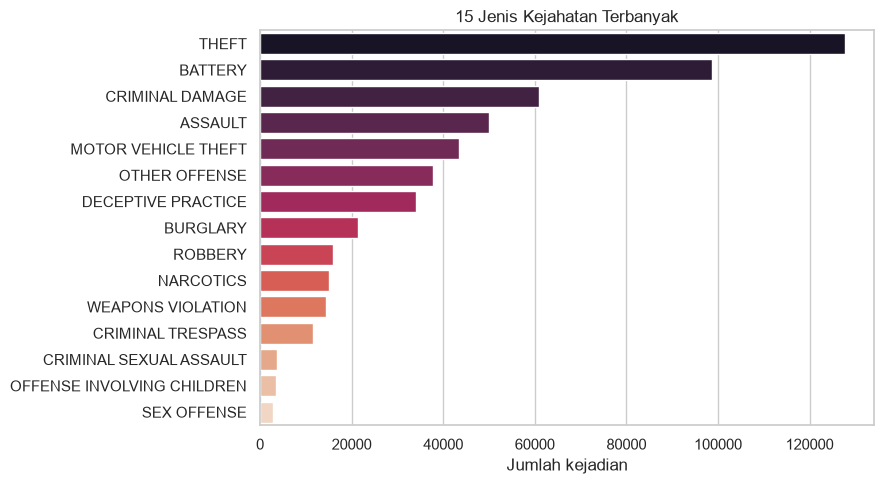

In [47]:
top_types = df["Primary Type"].value_counts().head(15)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_types.values, y=top_types.index, hue=top_types.index,
            palette="rocket", legend=False)
plt.title("15 Jenis Kejahatan Terbanyak")
plt.xlabel("Jumlah kejadian"); plt.ylabel("")
plt.tight_layout(); plt.show()

## 3.2 Pola Temporal — Jam, Hari, Bulan

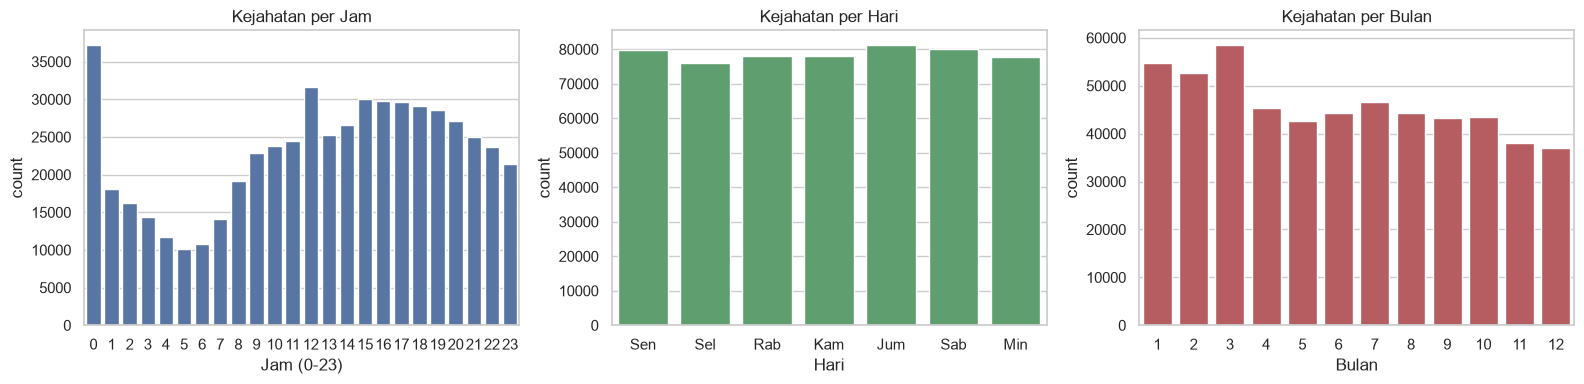

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Per jam
sns.countplot(x="hour", data=df, ax=axes[0], color="#4C72B0")
axes[0].set_title("Kejahatan per Jam"); axes[0].set_xlabel("Jam (0-23)")

# Per hari dalam seminggu
labels_dow = ["Sen","Sel","Rab","Kam","Jum","Sab","Min"]
sns.countplot(x="dow", data=df, order=[0,1,2,3,4,5,6], ax=axes[1], color="#55A868")
axes[1].set_title("Kejahatan per Hari"); axes[1].set_xlabel("Hari")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(labels_dow)

# Per bulan
sns.countplot(x="month", data=df, ax=axes[2], color="#C44E52")
axes[2].set_title("Kejahatan per Bulan"); axes[2].set_xlabel("Bulan")

plt.tight_layout(); plt.show()

## 3.3 Pola Spasial — Hotspot

Sebaran koordinat memperlihatkan **konsentrasi** kejahatan. `hexbin` cocok untuk
menunjukkan kepadatan tanpa terganggu jutaan titik yang saling menimpa.

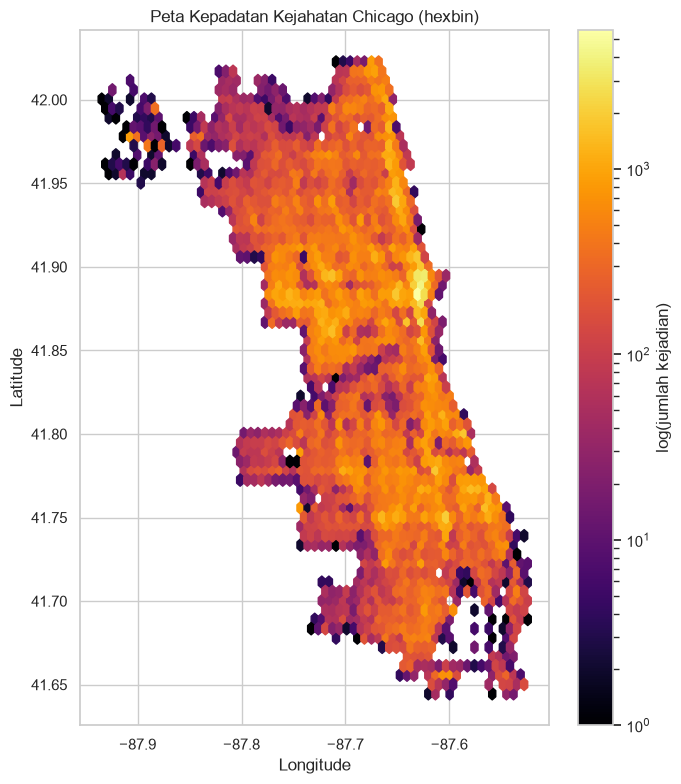

In [49]:
plt.figure(figsize=(7, 8))
hb = plt.hexbin(df["Longitude"], df["Latitude"], gridsize=60,
                cmap="inferno", mincnt=1, bins="log")
plt.colorbar(hb, label="log(jumlah kejadian)")
plt.title("Peta Kepadatan Kejahatan Chicago (hexbin)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

## 3.4 Weekday vs Weekend — pola per jam

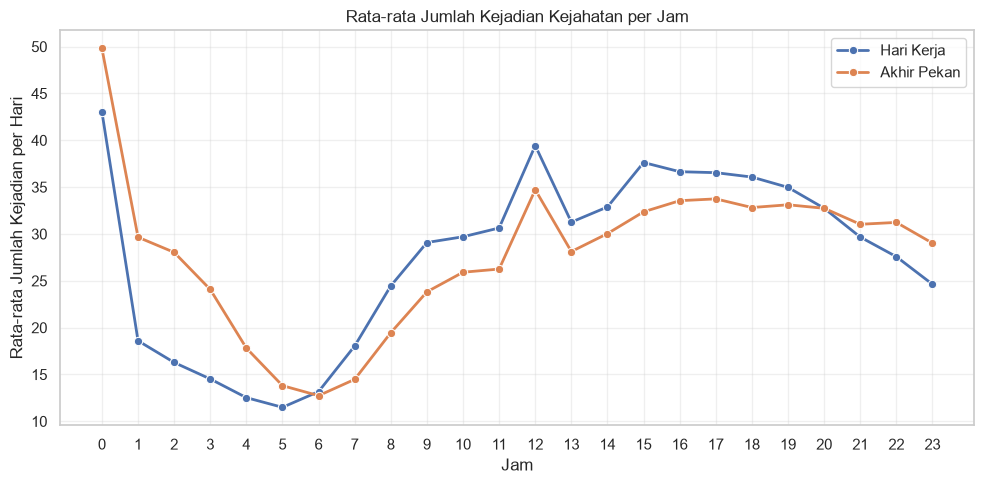

In [50]:
# Pastikan ada kolom tanggal
df["date"] = df["Datetime"].dt.date 
# Weekend = Sabtu dan Minggu
df["is_weekend_tmp"] = df["dow"].isin([5, 6])

# Hitung jumlah kejadian per tanggal per jam
hourly = (
    df.groupby(["is_weekend_tmp", "date", "hour"])
      .size()
      .reset_index(name="count")
)

# Rata-rata jumlah kejadian per hari pada setiap jam
hourly_avg = (
    hourly.groupby(["is_weekend_tmp", "hour"])["count"]
          .mean()
          .reset_index()
)

# Plot
plt.figure(figsize=(10,5))

sns.lineplot(
    data=hourly_avg[~hourly_avg["is_weekend_tmp"]],
    x="hour",
    y="count",
    marker="o",
    linewidth=2,
    label="Hari Kerja"
)

sns.lineplot(
    data=hourly_avg[hourly_avg["is_weekend_tmp"]],
    x="hour",
    y="count",
    marker="o",
    linewidth=2,
    label="Akhir Pekan"
)

plt.title("Rata-rata Jumlah Kejadian Kejahatan per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Jumlah Kejadian per Hari")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Bersihkan kolom sementara
df.drop(columns=["is_weekend_tmp"], inplace=True)

## 3.5 Interaksi Hari x Jam (heatmap) 

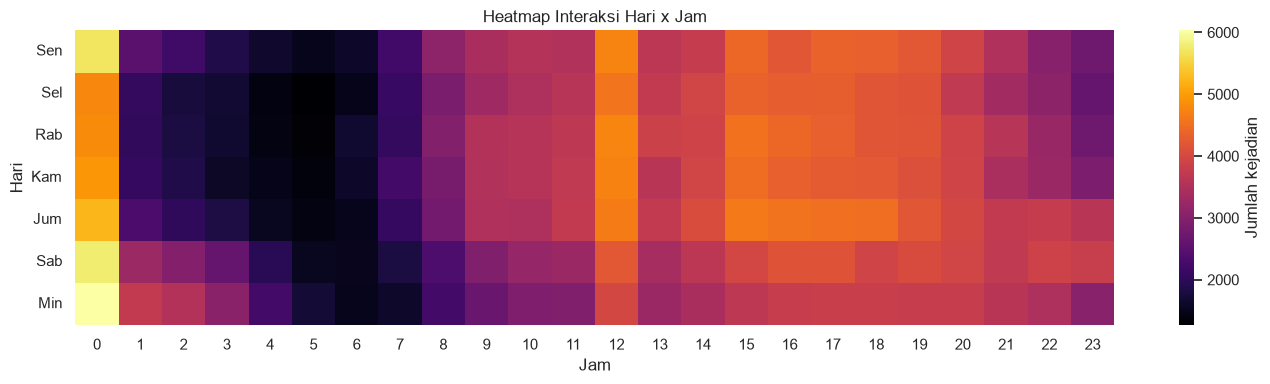

In [51]:
pivot_dow_hour = df.pivot_table(index="dow", columns="hour", values="ID", aggfunc="count")

labels_dow = ["Sen","Sel","Rab","Kam","Jum","Sab","Min"]

plt.figure(figsize=(14, 4))
sns.heatmap(pivot_dow_hour, cmap="inferno", cbar_kws={"label": "Jumlah kejadian"})
plt.yticks(np.arange(7) + 0.5, labels_dow, rotation=0)
plt.title("Heatmap Interaksi Hari x Jam")
plt.xlabel("Jam"); plt.ylabel("Hari")
plt.tight_layout(); plt.show()

## 3.6 Pola temporal untuk 5 jenis kejahatan teratas — apakah tiap jenis punya "jam sibuk" sendiri?

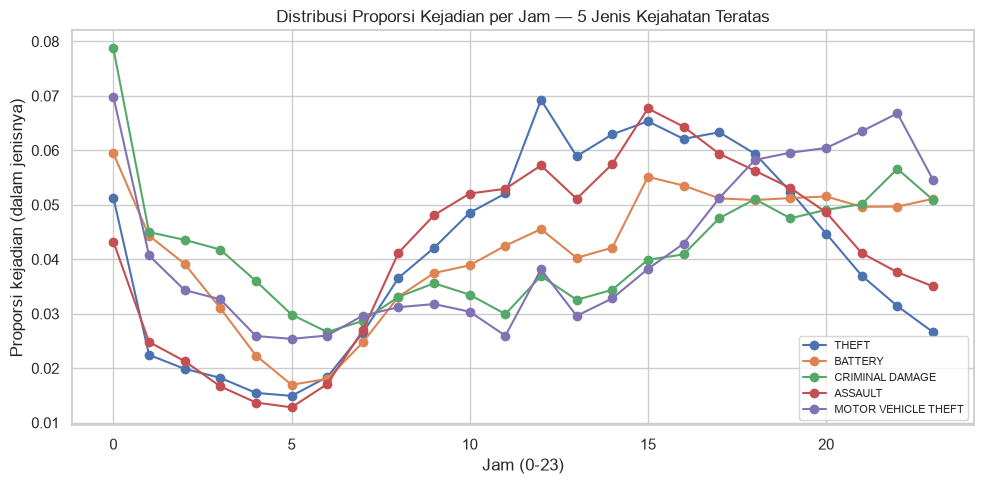

In [52]:
top5_types = df["Primary Type"].value_counts().head(5).index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
for crime_type in top5_types:
    subset = df[df["Primary Type"] == crime_type]
    hourly_dist = subset["hour"].value_counts(normalize=True).sort_index()
    ax.plot(hourly_dist.index, hourly_dist.values, marker="o", label=crime_type)

ax.set_title("Distribusi Proporsi Kejadian per Jam — 5 Jenis Kejahatan Teratas")
ax.set_xlabel("Jam (0-23)"); ax.set_ylabel("Proporsi kejadian (dalam jenisnya)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# 4. Feature Engineering

- **Temporal** — merepresentasikan sifat **siklikal** waktu.
- **Spasial** — mengagregasi lokasi kontinu menjadi **grid** yang bisa dibandingkan.

## 4.1 Fitur Temporal — Cyclical Encoding

Waktu bersifat **siklikal**: jam `23:00` sebenarnya *berdekatan* dengan `00:00`, tetapi
jika kita pakai angka mentah (`23` vs `0`) model akan menganggapnya **berjauhan**
(selisih 23). Dilakukan pemetaan setiap nilai siklikal ke **lingkaran** dengan `sin` & `cos`:

$$x_{\sin} = \sin\!\left(\frac{2\pi \cdot v}{P}\right), \qquad x_{\cos} = \cos\!\left(\frac{2\pi \cdot v}{P}\right)$$

dengan $P$ = panjang siklus (24 untuk jam, 7 untuk hari, 12 untuk bulan).

In [53]:
def cyclical_encode(values, period):
    # Ubah nilai siklikal menjadi pasangan (sin, cos)
    radians = 2 * np.pi * values / period
    return np.sin(radians), np.cos(radians)

df["hour_sin"], df["hour_cos"] = cyclical_encode(df["hour"], 24)
df["dow_sin"],  df["dow_cos"]  = cyclical_encode(df["dow"],  7)

df[["hour", "hour_sin", "hour_cos", "dow", "dow_sin", "dow_cos"]].head()

,hour,hour_sin,hour_cos,dow,dow_sin,dow_cos
0,0,0.0,1.0,5,-0.974928,-0.222521
2,0,0.0,1.0,5,-0.974928,-0.222521
3,0,0.0,1.0,5,-0.974928,-0.222521
4,0,0.0,1.0,5,-0.974928,-0.222521
5,0,0.0,1.0,5,-0.974928,-0.222521


**Cek jarak antar-jam pada bidang (sin, cos):**
`23:00` seharusnya lebih dekat ke `00:00` daripada ke `12:00`.

Jarak 23:00 -> 00:00 = 0.261  (harusnya KECIL)
Jarak 00:00 -> 12:00 = 2.000  (harusnya BESAR)


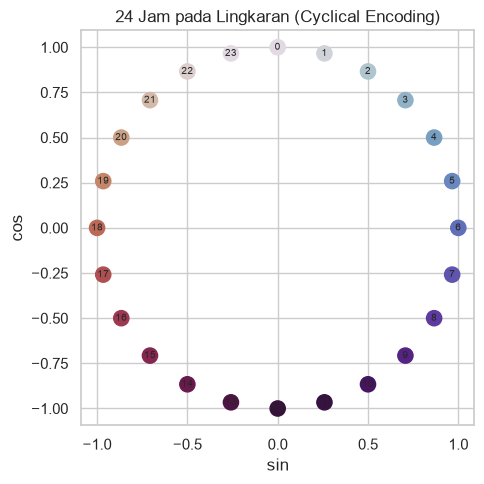

In [54]:
def point(v, p): return np.array(cyclical_encode(np.array([v]), p)).ravel()

d_23_to_0 = np.linalg.norm(point(23, 24) - point(0, 24))
d_0_to_12 = np.linalg.norm(point(0, 24)  - point(12, 24))
print(f"Jarak 23:00 -> 00:00 = {d_23_to_0:.3f}  (harusnya KECIL)")
print(f"Jarak 00:00 -> 12:00 = {d_0_to_12:.3f}  (harusnya BESAR)")

# Visualisasi 24 jam sebagai lingkaran
hs, hc = cyclical_encode(np.arange(24), 24)
plt.figure(figsize=(5,5))
plt.scatter(hs, hc, c=np.arange(24), cmap="twilight", s=120)
for h in range(24):
    plt.annotate(str(h), (hs[h], hc[h]), ha="center", va="center", fontsize=7)
plt.title("24 Jam pada Lingkaran (Cyclical Encoding)")
plt.xlabel("sin"); plt.ylabel("cos"); plt.axis("equal")
plt.tight_layout(); plt.show()

## 4.2 Fitur Spasial — Grid Aggregation

Koordinat lintang/bujur bersifat **kontinu & presisi tinggi** — dua titik yang selisihnya
sangat kecil praktis berada di lingkungan yang sama. Agar lokasi bisa **diagregasi dan
dibandingkan**, dilakukan **pembulatan koordinat** ke beberapa desimal,
sehingga titik-titik yang berdekatan jatuh ke *sel* yang sama.

In [55]:
# Asumsi:
# - Grid diperhalus dari 2 -> 3 desimal (~1.1km -> ~110m per sel). Konsekuensinya: sel makin banyak
#   dan makin banyak sel yang sepi kejadian (sparse), tapi resolusi lokasi jauh lebih relevan
#   untuk risiko "titik lokasi", bukan cuma "area besar".
# - Tambah fitur is_weekend (akhir pekan punya pola berbeda, lihat EDA di atas).
# - Tambah fitur is_violent sebagai penanda kejahatan dengan risiko fisik tinggi -> nanti
#   diagregasi jadi 'violent_share' per unit (proporsi kejadian kekerasan di sel tsb).

ROUND_DECIMALS = 3   # 3 desimal ~ 110m. Lebih halus dari baseline (2 desimal ~ 1.1km).

df["lat_r"] = df["Latitude"].round(ROUND_DECIMALS)
df["lon_r"] = df["Longitude"].round(ROUND_DECIMALS)
df["cell_id"] = df["lat_r"].astype(str) + "_" + df["lon_r"].astype(str)

print(f"Jumlah sel unik (grid {ROUND_DECIMALS} desimal): {df['cell_id'].nunique():,}")

# Cek tingkat kesparsitasan: berapa % sel yang cuma punya 1 kejadian?
cell_counts = df["cell_id"].value_counts()
pct_singleton = (cell_counts == 1).mean() * 100
print(f"Sel dengan hanya 1 kejadian: {pct_singleton:.1f}% dari total sel unik")
print("-> semakin halus grid, semakin sparse. Ini alasan kita butuh spatial smoothing di tahap 5.3.")


df[["Latitude", "Longitude", "lat_r", "lon_r", "cell_id"]].head()

Jumlah sel unik (grid 3 desimal): 38,330
Sel dengan hanya 1 kejadian: 12.7% dari total sel unik
-> semakin halus grid, semakin sparse. Ini alasan kita butuh spatial smoothing di tahap 5.3.


,Latitude,Longitude,lat_r,lon_r,cell_id
0,41.801025,-87.652621,41.801,-87.653,41.801_-87.653
2,41.884097,-87.675228,41.884,-87.675,41.884_-87.675
3,41.977655,-87.697553,41.978,-87.698,41.978_-87.698
4,41.954538,-87.651148,41.955,-87.651,41.955_-87.651
5,41.951894,-87.747276,41.952,-87.747,41.952_-87.747


# 5. Pseudo-Labeling → Membentuk **Risk Score**

Dataset kejahatan **tidak** memiliki kolom "Risk Score" (tidak ada *ground truth*).
**Pseudo-labeling** adalah teknik membentuk label target dari **domain knowledge**.
Dibangun Risk Score dalam beberapa langkah: **severity → temporal decay → spatial
aggregation → normalisasi 0–100**.

## 5.1 Severity Scoring

Setiap kejahatan diberi skor keparahan berdasarkan kombinasi **Primary Type + Description**.

## 5.1 Severity Scoring — Metodologi Bertingkat (3-Tier)

**Solusi: fallback bertingkat (3-tier).**

| Tier | Kondisi | Sumber nilai |
|---|---|---|
| 1 — Exact match | Kombinasi `(Primary Type, Description)` ada di tabel manual | Nilai spesifik yang di-assign manual |
| 2 — Fallback per Primary Type | Kombinasi spesifik tidak ada, tapi `Primary Type`-nya dikenal | Nilai representatif untuk `Primary Type` itu |
| 3 — Fallback global | `Primary Type`-nya sendiri benar-benar tidak dikenal/langka | Satu nilai default terakhir, seharusnya sangat jarang dipakai |

**Dasar penyusunan nilai :** urutan keparahan mengikuti *Hierarchy Rule* yang dipakai FBI UCR — daftar resmi mengurutkan kejahatan dari yang paling serius:
*murder → rape → robbery → aggravated assault → burglary → larceny-theft → motor vehicle theft* (arson dihitung terpisah). Urutan ini dipakai sebagai **kerangka ordinal** (kejahatan mana lebih berat dari mana), lalu diberi angka 0–100 dengan jarak antar-tingkat yang mencerminkan tingkat ancaman terhadap keselamatan (nyawa > kekerasan fisik > kerugian materi), bukan berdasarkan seberapa sering kejadian itu muncul di data (justru kejahatan paling berat, seperti `HOMICIDE`, biasanya paling jarang terjadi).

In [73]:
# TIER 1: tabel manual untuk kombinasi (Primary Type, Description) yang spesifik.
# kombinasi mana yang paling sering muncul tapi belum ada di tabel.

severity_table = {
    # ==========================================================
    # HOMICIDE
    # ==========================================================
    ("HOMICIDE", "FIRST DEGREE MURDER"): 100,

    # ==========================================================
    # CRIMINAL SEXUAL ASSAULT / SEX OFFENSE
    # ==========================================================
    ("CRIMINAL SEXUAL ASSAULT", "AGGRAVATED"): 95,
    ("CRIMINAL SEXUAL ASSAULT", "NON-AGGRAVATED"): 85,

    ("SEX OFFENSE", "CRIMINAL SEXUAL ABUSE"): 75,
    ("SEX OFFENSE", "PUBLIC INDECENCY"): 20,

    # ==========================================================
    # ROBBERY
    # ==========================================================
    ("ROBBERY", "AGGRAVATED"): 75,
    ("ROBBERY", "ARMED - HANDGUN"): 82,
    ("ROBBERY", "STRONG ARM - NO WEAPON"): 60,
    ("ROBBERY", "AGGRAVATED VEHICULAR HIJACKING"): 90,

    # ==========================================================
    # ASSAULT
    # ==========================================================
    ("ASSAULT", "SIMPLE"): 45,
    ("ASSAULT", "AGGRAVATED - HANDGUN"): 78,
    ("ASSAULT", "AGGRAVATED - OTHER DANGEROUS WEAPON"): 70,
    ("ASSAULT", "AGGRAVATED - KNIFE / CUTTING INSTRUMENT"): 72,

    # ==========================================================
    # BATTERY
    # ==========================================================
    ("BATTERY", "SIMPLE"): 50,
    ("BATTERY", "DOMESTIC BATTERY SIMPLE"): 52,
    ("BATTERY", "AGGRAVATED - HANDGUN"): 78,
    ("BATTERY", "AGGRAVATED - OTHER DANGEROUS WEAPON"): 70,

    # ==========================================================
    # WEAPONS VIOLATION
    # ==========================================================
    ("WEAPONS VIOLATION", "UNLAWFUL POSSESSION - HANDGUN"): 58,
    ("WEAPONS VIOLATION", "RECKLESS FIREARM DISCHARGE"): 65,

    # ==========================================================
    # BURGLARY
    # ==========================================================
    ("BURGLARY", "FORCIBLE ENTRY"): 48,
    ("BURGLARY", "UNLAWFUL ENTRY"): 42,
    ("BURGLARY", "ATTEMPT FORCIBLE ENTRY"): 40,
    ("BURGLARY", "BURGLARY FROM MOTOR VEHICLE"): 35,

    # ==========================================================
    # MOTOR VEHICLE THEFT
    # ==========================================================
    ("MOTOR VEHICLE THEFT", "AUTOMOBILE"): 40,
    ("MOTOR VEHICLE THEFT", "ATTEMPT - AUTOMOBILE"): 30,
    ("MOTOR VEHICLE THEFT", "THEFT / RECOVERY - AUTOMOBILE"): 35,
    ("MOTOR VEHICLE THEFT", "TRUCK, BUS, MOTOR HOME"): 35,

    # ==========================================================
    # THEFT
    # ==========================================================
    ("THEFT", "POCKET-PICKING"): 32,
    ("THEFT", "OVER $500"): 28,
    ("THEFT", "$500 AND UNDER"): 20,
    ("THEFT", "RETAIL THEFT"): 18,
    ("THEFT", "FROM BUILDING"): 22,
    ("THEFT", "THEFT FROM MOTOR VEHICLE"): 22,
    ("THEFT", "PURSE-SNATCHING"): 35,
    ("THEFT", "ATTEMPT THEFT"): 15,

    # ==========================================================
    # NARCOTICS
    # ==========================================================
    ("NARCOTICS", "POSSESS - CANNABIS 30 GRAMS OR LESS"): 22,
    ("NARCOTICS", "POSSESS - HEROIN (WHITE)"): 30,
    ("NARCOTICS", "POSSESS - CRACK"): 28,
    ("NARCOTICS", "POSSESSION OF DRUG EQUIPMENT"): 18,
    ("NARCOTICS", "ATTEMPT POSSESSION NARCOTICS"): 20,
    ("NARCOTICS", "FOUND SUSPECT NARCOTICS"): 15,

    # ==========================================================
    # CRIMINAL DAMAGE
    # ==========================================================
    ("CRIMINAL DAMAGE", "TO VEHICLE"): 12,
    ("CRIMINAL DAMAGE", "TO PROPERTY"): 12,
    ("CRIMINAL DAMAGE", "CRIMINAL DEFACEMENT"): 12,
    ("CRIMINAL DAMAGE", "TO CITY OF CHICAGO PROPERTY"): 12,

    # ==========================================================
    # CRIMINAL TRESPASS
    # ==========================================================
    ("CRIMINAL TRESPASS", "TO LAND"): 10,
    ("CRIMINAL TRESPASS", "TO RESIDENCE"): 18,
    ("CRIMINAL TRESPASS", "TO STATE SUP LAND"): 10,
    ("CRIMINAL TRESPASS", "TO VEHICLE"): 12,

    # ==========================================================
    # DECEPTIVE PRACTICE
    # ==========================================================
    ("DECEPTIVE PRACTICE", "FINANCIAL IDENTITY THEFT OVER $ 300"): 25,
    ("DECEPTIVE PRACTICE", "FINANCIAL IDENTITY THEFT $300 AND UNDER"): 20,
    ("DECEPTIVE PRACTICE", "FRAUD OR CONFIDENCE GAME"): 20,
    ("DECEPTIVE PRACTICE", "FORGERY"): 20,
    ("DECEPTIVE PRACTICE", "BOGUS CHECK"): 18,
    ("DECEPTIVE PRACTICE", "COUNTERFEITING DOCUMENT"): 20,
    ("DECEPTIVE PRACTICE", "CREDIT CARD FRAUD"): 15,
    ("DECEPTIVE PRACTICE", "ILLEGAL USE CASH CARD"): 15,

    # ==========================================================
    # OTHER OFFENSE
    # ==========================================================
    ("OTHER OFFENSE", "VIOLATE ORDER OF PROTECTION"): 30,
    ("OTHER OFFENSE", "TELEPHONE THREAT"): 20,
    ("OTHER OFFENSE", "HARASSMENT BY TELEPHONE"): 15,
    ("OTHER OFFENSE", "HARASSMENT BY ELECTRONIC MEANS"): 15,
    ("OTHER OFFENSE", "FALSE / STOLEN / ALTERED TRP"): 10,
    ("OTHER OFFENSE", "OTHER VEHICLE OFFENSE"): 12,
    ("OTHER OFFENSE", "OTHER CRIME INVOLVING PROPERTY"): 12,

    # ==========================================================
    # PROSTITUTION
    # ==========================================================
    ("PROSTITUTION", "SOLICIT ON PUBLIC WAY"): 18,

    # ==========================================================
    # PUBLIC PEACE VIOLATION
    # ==========================================================
    ("PUBLIC PEACE VIOLATION", "RECKLESS CONDUCT"): 18,

    # ==========================================================
    # OFFENSE INVOLVING CHILDREN
    # ==========================================================
    ("OFFENSE INVOLVING CHILDREN", "CHILD ABUSE"): 85,

    # ==========================================================
    # ARSON
    # ==========================================================
    ("ARSON", "BY FIRE"): 60,
}

# TIER 2: kalau kombinasi spesifiknya nggak ketemu, fallback ke rata-rata per Primary Type.
# Angkanya disusun berdasar urutan keparahan ala UCR + logika ancaman ke keselamatan publik.

primary_type_default = {
    "HOMICIDE":                98,
    "CRIMINAL SEXUAL ASSAULT": 90,   
    "KIDNAPPING":              88,
    "ROBBERY":                 72,
    "WEAPONS VIOLATION":       60,
    "ASSAULT":                 52,
    "BATTERY":                 50,
    "ARSON":                   55,
    "BURGLARY":                45,
    "MOTOR VEHICLE THEFT":     38,
    "NARCOTICS":               28,
    "THEFT":                   25,
    "DECEPTIVE PRACTICE":      20,
    "CRIMINAL DAMAGE":         15,
    "CRIMINAL TRESPASS":       15,
    "PUBLIC PEACE VIOLATION":  15,
    "OTHER OFFENSE":           18,
    "LIQUOR LAW VIOLATION":    10,
    "GAMBLING":                10,
    "INTIMIDATION":            35,
    "STALKING":                45,
    "OFFENSE INVOLVING CHILDREN": 80,
    "HUMAN TRAFFICKING":       92,
    "CONCEALED CARRY LICENSE VIOLATION": 25,
    "PROSTITUTION": 18,
    "SEX OFFENSE": 60,
}

# TIER 3: fallback terakhir kalau Primary Type-nya sendiri nggak dikenali -- harusnya jarang kepakai
GLOBAL_DEFAULT_SEVERITY = 20

In [74]:
exact_key = list(zip(df["Primary Type"], df["Description"]))
exact_severity = pd.Series(exact_key, index=df.index).map(severity_table)

type_fallback_severity = df["Primary Type"].map(primary_type_default)

df["severity"] = exact_severity.fillna(type_fallback_severity).fillna(GLOBAL_DEFAULT_SEVERITY)

df["severity_tier"] = np.select(
    [exact_severity.notna(), type_fallback_severity.notna()],
    ["1_exact_match", "2_type_fallback"],
    default="3_global_default",
)

tier_pct = df["severity_tier"].value_counts(normalize=True).mul(100).round(1)
print("Distribusi tier severity (%):")
print(tier_pct)
print()
print("Kalau tier 3 (global default) masih besar persentasenya, tabel di atas PERLU DIPERLUAS.")

Distribusi tier severity (%):
severity_tier
1_exact_match       89.9
2_type_fallback      9.7
3_global_default     0.4
Name: proportion, dtype: float64

Kalau tier 3 (global default) masih besar persentasenya, tabel di atas PERLU DIPERLUAS.


In [58]:
# Semua kombinasi unik di dataset
comb = (
    df.groupby(["Primary Type", "Description"])
      .size()
      .reset_index(name="freq")
)

# Cek apakah kombinasi sudah ada di severity_table
comb["in_table"] = comb.apply(
    lambda r: (r["Primary Type"], r["Description"]) in severity_table,
    axis=1
)

# Kombinasi yang belum ada
missing = (
    comb[~comb["in_table"]]
    .sort_values("freq", ascending=False)
)

print(missing.head(50))

                         Primary Type  \
21                            BATTERY   
31                            BATTERY   
261                     OTHER OFFENSE   
26                            BATTERY   
112                DECEPTIVE PRACTICE   
36                            BATTERY   
173                         NARCOTICS   
187                         NARCOTICS   
111                DECEPTIVE PRACTICE   
45                            BATTERY   
30                            BATTERY   
34                            BATTERY   
85                 DECEPTIVE PRACTICE   
83                 DECEPTIVE PRACTICE   
248                     OTHER OFFENSE   
244                     OTHER OFFENSE   
235                     OTHER OFFENSE   
129  INTERFERENCE WITH PUBLIC OFFICER   
188                         NARCOTICS   
297                           ROBBERY   
109                DECEPTIVE PRACTICE   
328                          STALKING   
218        OFFENSE INVOLVING CHILDREN   
134  INTERFERENC

In [59]:
# Diagnostik: kombinasi mana yang paling sering jatuh ke tier 2/3 -> prioritas untuk
# ditambahkan ke severity_table secara manual (mengikuti prinsip Pareto: lengkapi dulu
# kombinasi yang paling SERING muncul, karena itu paling berdampak ke Risk Score akhir).
df[df["severity_tier"] != "1_exact_match"][["Primary Type", "Description"]] \
  .value_counts().head(30)

Primary Type                      Description                                               
BATTERY                           AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SERIOUS INJURY    2278
                                  AGGRAVATED DOMESTIC BATTERY - OTHER DANGEROUS WEAPON          2032
OTHER OFFENSE                     VEHICLE TITLE / REGISTRATION OFFENSE                          1844
BATTERY                           AGGRAVATED - KNIFE / CUTTING INSTRUMENT                       1825
DECEPTIVE PRACTICE                THEFT OF LOST / MISLAID PROPERTY                              1716
BATTERY                           AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MINOR INJURY       1544
NARCOTICS                         MANUFACTURE / DELIVER - CANNABIS OVER 10 GRAMS                1521
                                  POSSESS - CANNABIS MORE THAN 30 GRAMS                         1484
DECEPTIVE PRACTICE                THEFT OF LABOR / SERVICES                                     128

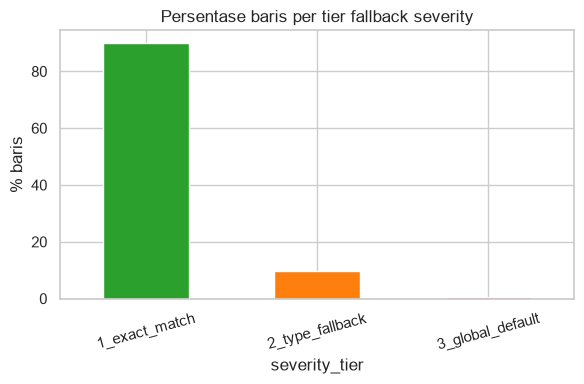

In [60]:
fig, ax = plt.subplots(figsize=(6, 4))
tier_pct.plot(kind="bar", color=["#2ca02c", "#ff7f0e", "#d62728"], ax=ax)
ax.set_title("Persentase baris per tier fallback severity")
ax.set_ylabel("% baris")
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## 5.2 Temporal Decay — Recency

`w_time = exp(-λ · Δt)` : kejadian lebih baru menimbang lebih besar.
Baseline di bawah pakai **exponential decay dengan half-life**, alternatif yang lebih umum dipakai dibanding linear decay.

In [61]:
REFERENCE_DATE = df["Datetime"].max()   # "sekarang" menurut data
df["age_days"] = (REFERENCE_DATE - df["Datetime"]).dt.total_seconds() / 86400

# Peluruhan LINEAR sederhana: 1.0 di hari terbaru -> ~0 di data tertua
max_age = df["age_days"].max()
df["w_time"] = 1 - (df["age_days"] / max_age)     # rentang 0..1

# Kontribusi tiap kejadian = severity x bobot recency
df["event_value"] = df["severity"] * df["w_time"]

print(f"Reference date : {REFERENCE_DATE}")
print(f"w_time range   : {df['w_time'].min():.3f} .. {df['w_time'].max():.3f}")
df[["Datetime", "age_days", "w_time", "severity", "event_value"]].head()

Reference date : 2026-04-11 00:00:00
w_time range   : 0.000 .. 1.000


,Datetime,age_days,w_time,severity,event_value
0,2026-04-11,0.0,1.0,20.0,20.0
2,2026-04-11,0.0,1.0,50.0,50.0
3,2026-04-11,0.0,1.0,20.0,20.0
4,2026-04-11,0.0,1.0,22.0,22.0
5,2026-04-11,0.0,1.0,50.0,50.0


HALF_LIFE_DAYS = 180
w_time range   : 0.0408 .. 1.0000


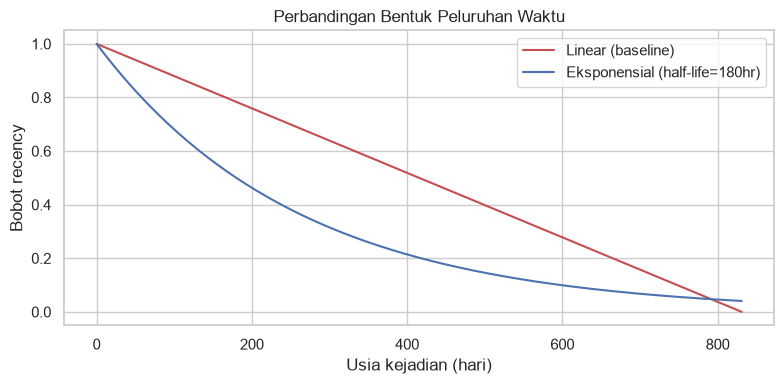

         age_days      w_time
count  550896.000  550896.000
mean      427.927       0.285
std       236.914       0.249
min         0.000       0.041
25%       226.375       0.087
50%       434.795       0.187
75%       633.750       0.418
max       831.000       1.000


In [62]:
# Asumsi: peluruhan linear membuat kejadian tertua bobotnya PERSIS 0 (informasinya hilang total),
# padahal kejahatan lama tetap punya sedikit relevansi (pola lokasi cenderung persisten).
# Eksponensial/half-life lebih masuk akal: relevansi berkurang SEPARUH setiap periode tertentu,
# tapi tidak pernah benar-benar nol.

# HALF_LIFE_DAYS = 180 (~6 bulan): asumsi bahwa pola kejahatan di suatu lokasi cukup persisten
# dalam skala bulanan-tahunan, tapi kejadian setahun lalu relevansinya sudah tinggal ~25%.

HALF_LIFE_DAYS = 180

df["w_time"] = 0.5 ** (df["age_days"] / HALF_LIFE_DAYS)
df["event_value"] = df["severity"] * df["w_time"]

print(f"HALF_LIFE_DAYS = {HALF_LIFE_DAYS}")
print(f"w_time range   : {df['w_time'].min():.4f} .. {df['w_time'].max():.4f}")

# Bandingkan bentuk kurva linear (baseline) vs eksponensial
age_range = np.linspace(0, df["age_days"].max(), 200)
w_linear = 1 - (age_range / df["age_days"].max())
w_exp = 0.5 ** (age_range / HALF_LIFE_DAYS)

plt.figure(figsize=(8, 4))
plt.plot(age_range, w_linear, label="Linear (baseline)", color="#C44E52")
plt.plot(age_range, w_exp, label=f"Eksponensial (half-life={HALF_LIFE_DAYS}hr)", color="#4C72B0")
plt.title("Perbandingan Bentuk Peluruhan Waktu")
plt.xlabel("Usia kejadian (hari)"); plt.ylabel("Bobot recency")
plt.legend(); plt.tight_layout(); plt.show()

df[["Datetime", "age_days", "w_time", "severity", "event_value"]].head()
print(df[["age_days", "w_time"]].describe().round(3))

Setengah bobot penuh sudah hilang di titik `HALF_LIFE_DAYS`, dan sisanya makin kecil setelahnya, ini yang membuat kejadian baru lebih menentukan Risk Score dibanding kejadian lama, tanpa sepenuhnya mengabaikan histori.

### Membentuk tabel unit analisis (sel × hari × jam)

Jumlahkan `event_value` (severity × recency) ke tiap unit analisis, jadi `base_value`. Sekaligus bawa `crime_count` (frekuensi kejadian) sebagai fitur agregat tambahan, berbeda sifatnya dari `base_value` (yang menimbang keparahan × kebaruan).

In [64]:
unit = (df.groupby(["cell_id", "lat_r", "lon_r", "dow", "hour"], as_index=False)
          .agg(base_value  = ("event_value", "sum"),
               crime_count = ("ID", "size")))
print("Jumlah baris unit (sel × hari × jam):", f"{len(unit):,}")
unit.head()

Jumlah baris unit (sel × hari × jam): 457,696


,cell_id,lat_r,lon_r,dow,hour,base_value,crime_count
0,41.645_-87.54,41.645,-87.54,0,5,20.434911,1
1,41.645_-87.54,41.645,-87.54,0,9,9.842863,2
2,41.645_-87.54,41.645,-87.54,1,0,10.062383,1
3,41.645_-87.54,41.645,-87.54,1,9,40.281507,1
4,41.645_-87.54,41.645,-87.54,2,7,3.256597,1


## 5.3 Spatial Aggregation — Proximity

`w_dist = exp(-d² / 2σ²)` : sinyal dari sel dekat lebih relevan.
Baseline di bawah pakai `BallTree` (scikit-learn) dengan metrik `haversine` untuk menghitung **jarak sesungguhnya antar-koordinat** (dalam meter), lalu bobot Gaussian berdasarkan jarak itu — lebih presisi dibanding sekadar mengambil "8 sel tetangga" secara kasar.

In [65]:
# Asumsi: dibanding grid tetangga 3x3 tanpa jarak (baseline), kita pakai jarak geografis
# sesungguhnya (haversine) via BallTree, dengan bobot menurun secara Gaussian terhadap jarak.
# RADIUS_KM = 3.0   -> radius pencarian tetangga (di luar ini dianggap tak relevan)
# BANDWIDTH_KM = 1.5 -> skala peluruhan kernel: pada jarak ini bobot sudah turun signifikan.
# Smoothing dilakukan PER IRISAN (dow, hour) yang sama, supaya makna "risiko pada waktu itu"
# tetap terjaga -- kita tidak mencampur risiko Senin pagi dengan Sabtu malam.

from sklearn.neighbors import BallTree

RADIUS_KM = 3.0
BANDWIDTH_KM = 1.5
EARTH_RADIUS_KM = 6371.0

def gaussian_kernel(distance_km, bandwidth_km):
    return np.exp(-0.5 * (distance_km / bandwidth_km) ** 2)

smoothed_parts = []

for (dow_val, hour_val), grp in unit.groupby(["dow", "hour"]):
    grp = grp.reset_index(drop=True)
    coords_rad = np.radians(grp[["lat_r", "lon_r"]].values)

    tree = BallTree(coords_rad, metric="haversine")
    radius_rad = RADIUS_KM / EARTH_RADIUS_KM
    neighbor_idx, neighbor_dist_rad = tree.query_radius(
        coords_rad, r=radius_rad, return_distance=True
    )

    base_vals = grp["base_value"].values
    risk_raw_vals = np.empty(len(grp))

    for i in range(len(grp)):
        d_km = neighbor_dist_rad[i] * EARTH_RADIUS_KM
        weights = gaussian_kernel(d_km, BANDWIDTH_KM)
        risk_raw_vals[i] = np.average(base_vals[neighbor_idx[i]], weights=weights)

    grp["risk_raw"] = risk_raw_vals
    smoothed_parts.append(grp)

unit = pd.concat(smoothed_parts, ignore_index=True)

print("risk_raw range:", round(unit["risk_raw"].min(), 2), "..",
      round(unit["risk_raw"].max(), 2))
unit[["cell_id", "dow", "hour", "base_value", "risk_raw"]].head()

risk_raw range: 0.94 .. 57.75


,cell_id,dow,hour,base_value,risk_raw
0,41.649_-87.54,0,0,31.365406,18.066234
1,41.649_-87.546,0,0,20.000000,18.125315
2,41.651_-87.527,0,0,8.618011,17.461713
3,41.651_-87.545,0,0,38.481107,17.816513
4,41.652_-87.61,0,0,4.422352,15.309975


## 5.4 Normalisasi → Risk Score 0–100

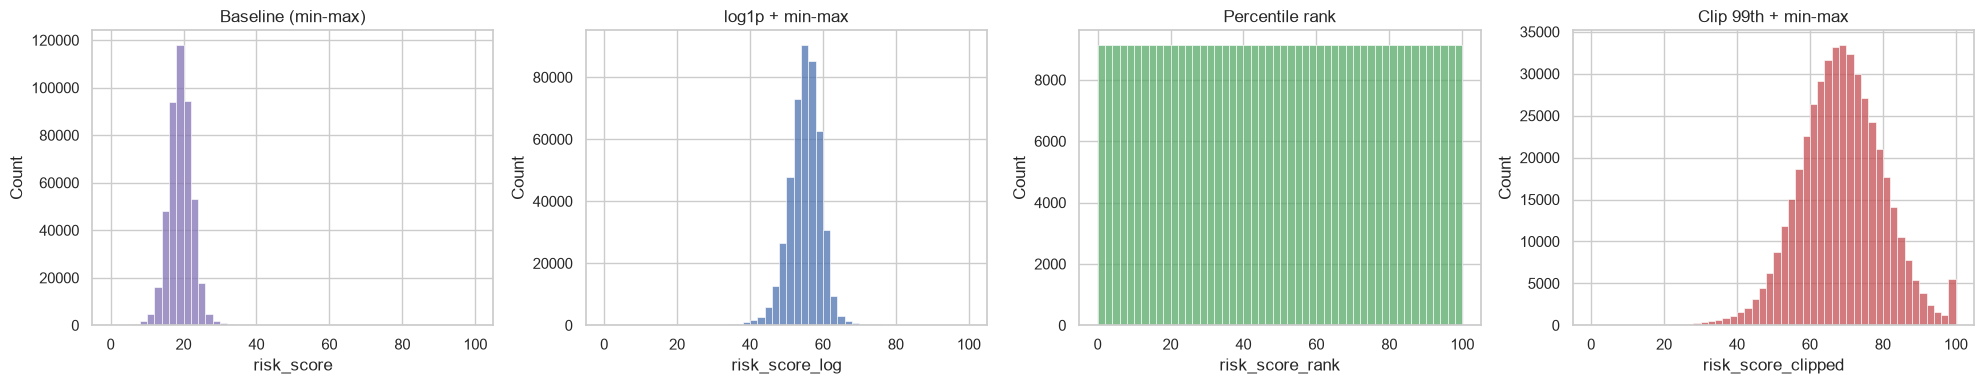

count    457696.00
mean         55.00
std           4.49
min           0.00
25%          52.45
50%          55.25
75%          57.86
max         100.00
Name: risk_score, dtype: float64


In [66]:
# Asumsi: min-max langsung (baseline) rentan outlier -- satu sel ekstrem bisa menekan
# semua sel lain mendekati 0. Kita bandingkan 3 alternatif, lalu pilih log1p sebagai versi
# final karena tetap mempertahankan urutan magnitude (beda dengan percentile rank yang
# menghilangkan info seberapa jauh perbedaannya).

# 1: Baseline (min-max)
rr = unit["risk_raw"]
unit["risk_score"] = 100 * (rr - rr.min()) / (rr.max() - rr.min())

# 2: log1p sebelum scaling -> menekan ekor kanan yang panjang
rr_log = np.log1p(unit["risk_raw"])
unit["risk_score_log"] = 100 * (rr_log - rr_log.min()) / (rr_log.max() - rr_log.min())

# 3: percentile rank -> paling robust thd outlier ekstrem, tapi mengabaikan magnitude asli
unit["risk_score_rank"] = unit["risk_raw"].rank(pct=True) * 100

# 4: clipping pada kuantil atas (99th percentile) lalu min-max
upper_clip = unit["risk_raw"].quantile(0.99)
rr_clipped = unit["risk_raw"].clip(upper=upper_clip)
unit["risk_score_clipped"] = 100 * (rr_clipped - rr_clipped.min()) / (rr_clipped.max() - rr_clipped.min())

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
sns.histplot(unit["risk_score"], bins=50, color="#8172B3", ax=axes[0]); axes[0].set_title("Baseline (min-max)")
sns.histplot(unit["risk_score_log"], bins=50, color="#4C72B0", ax=axes[1]); axes[1].set_title("log1p + min-max")
sns.histplot(unit["risk_score_rank"], bins=50, color="#55A868", ax=axes[2]); axes[2].set_title("Percentile rank")
sns.histplot(unit["risk_score_clipped"], bins=50, color="#C44E52", ax=axes[3]); axes[3].set_title("Clip 99th + min-max")
plt.tight_layout(); plt.show()

# Pilih versi final: log1p + min-max
unit["risk_score"] = unit["risk_score_log"]
unit.drop(columns=["risk_score_log", "risk_score_rank", "risk_score_clipped"], inplace=True)

print(unit["risk_score"].describe().round(2))

#### **Perbandingan Metode Normalisasi Risk Score**

Dari histogram perbandingan 4 metode normalisasi di atas, dapat disimpulkan
bahwa **`log1p + min-max` adalah metode terbaik** untuk merepresentasikan
Risk Score final:

**1. Baseline (min-max langsung)**
Distribusi masih sangat *skewed* --- mayoritas sel menumpuk di rentang
10--30, sementara sisanya nyaris kosong hingga ke 100. Ini membuktikan
masalah yang sudah diperingatkan di notebook: beberapa sel dengan
`risk_raw` ekstrem menekan seluruh sel lain ke rentang sempit, sehingga
sulit membedakan tingkat risiko antar-lokasi.

**2. `log1p + min-max` (dipilih sebagai versi final)**
Distribusi menjadi mendekati simetris/normal, berpusat di sekitar 50--60,
dan memanfaatkan rentang 0--100 secara jauh lebih merata. Yang terpenting,
**urutan magnitude tetap terjaga** --- sel dengan `risk_raw` yang jauh
lebih besar tetap memiliki skor lebih besar setelah transformasi, hanya
selisihnya yang dikompres. Sifat ini membuatnya paling representatif
sebagai fitur/label numerik untuk model regresi di Hands-On 2.

**3. Percentile rank**
Distribusi menjadi persis *uniform* (rata sempurna 0--100) --- ini memang
sifat alami dari rank. Namun metode ini **membuang informasi magnitude**:
dua sel dengan `risk_raw` yang beda tipis (persentil 49 vs 51) dianggap
"berbeda" sama besarnya dengan dua sel yang `risk_raw`-nya beda jauh
(persentil 10 vs 90). Untuk merepresentasikan "seberapa besar risiko",
ini kurang tepat --- lebih cocok dipakai kalau tujuannya sekadar
*ranking*/prioritas, bukan skor kontinu.

**4. Clip 99th + min--max**
Distribusi masih agak *skewed* ke kanan, dan muncul **spike artifisial
tepat di 100** --- ini adalah efek dari clipping: seluruh sel yang
awalnya berada di atas persentil ke-99 (padahal `risk_raw`-nya bervariasi)
dipepetkan menjadi nilai yang identik. Ironisnya, hal ini justru
menghilangkan detail pada sel-sel dengan risiko **tertinggi**, padahal
area itulah yang paling penting untuk dibedakan (mana hotspot yang benar-
benar paling gawat).


**Kesimpulan:** `log1p + min-max` dipilih sebagai metode normalisasi
final karena:
- Distribusi lebih simetris → representasi risiko lebih "adil" di
  seluruh rentang skor.
- Tidak menimbulkan *pileup* artifisial di salah satu ujung (berbeda
  dengan clipping).
- Tetap mempertahankan *ordering* magnitude asli dari `risk_raw`,
  berbeda dengan percentile rank yang menghilangkan informasi tersebut.

### Visualisasi peta risiko
Rata-rata Risk Score per sel — memastikan hasilnya sejalan dengan hotspot di EDA.

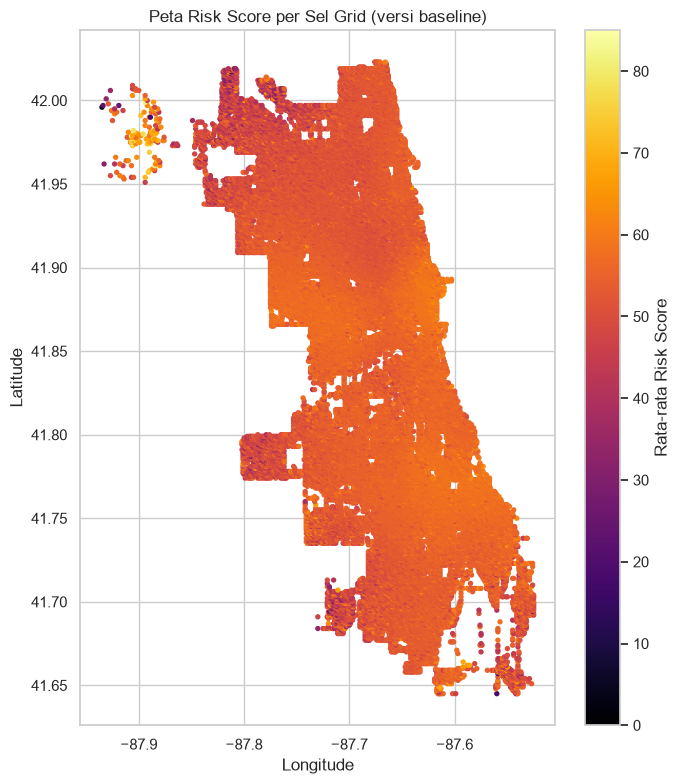

In [67]:
cell_risk = unit.groupby(["lat_r", "lon_r"], as_index=False)["risk_score"].mean()

plt.figure(figsize=(7, 8))
sc = plt.scatter(cell_risk["lon_r"], cell_risk["lat_r"], c=cell_risk["risk_score"],
                 cmap="inferno", s=8)
plt.colorbar(sc, label="Rata-rata Risk Score")
plt.title("Peta Risk Score per Sel Grid (versi baseline)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

# 6. Menyusun & Menyimpan Dataset Akhir

Dataset akhir berisi **fitur + label** per unit analisis (sel × hari × jam), siap menjadi
input Hands-On 2 (modeling). Kita tambahkan fitur temporal **cyclical** pada level unit
agar langsung bisa dipakai model.

In [69]:
# Fitur temporal cyclical pada level unit.
# Catatan: kita bawa hour & dow (dipakai sebagai unit analisis). 'month' TIDAK ikut ke
# unit karena unit kita beragregasi per (sel × hari × jam) — bulan sudah "lebur" di dalamnya.
# Kalau kalian ingin bulan sebagai fitur, unit analisisnya perlu memasukkan bulan juga.
unit["hour_sin"], unit["hour_cos"] = cyclical_encode(unit["hour"], 24)
unit["dow_sin"],  unit["dow_cos"]  = cyclical_encode(unit["dow"], 7)

final = unit[[
    # identitas / lokasi
    "cell_id", "lat_r", "lon_r",
    # fitur temporal (mentah + cyclical)
    "dow", "hour", "hour_sin", "hour_cos", "dow_sin", "dow_cos", 
    # fitur agregat (frekuensi & karakteristik kejadian per unit)
    "crime_count",
    # LABEL
    "risk_score",
]].copy()

print("Shape dataset akhir:", final.shape)
final.head()

Shape dataset akhir: (457696, 11)


,cell_id,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,crime_count,risk_score
0,41.649_-87.54,41.649,-87.540,0,0,0.0,1.0,0.0,1.0,2,66.985934
1,41.649_-87.546,41.649,-87.546,0,0,0.0,1.0,0.0,1.0,1,67.076701
2,41.651_-87.527,41.651,-87.527,0,0,0.0,1.0,0.0,1.0,1,66.040703
3,41.651_-87.545,41.651,-87.545,0,0,0.0,1.0,0.0,1.0,1,66.599155
4,41.652_-87.61,41.652,-87.610,0,0,0.0,1.0,0.0,1.0,1,62.405212


In [78]:
import pyarrow
print(pyarrow.__version__)

final.to_csv("../data/dataset/features_labels.csv", index=False)
print("Tersimpan: data/dataset/features_labels.csv ✅")

try:
    final.to_parquet("../data/dataset/features_labels.parquet", index=False)
    print("Tersimpan: data/dataset/features_labels.parquet ✅")
except Exception as e:
    print("Parquet dilewati (engine belum terpasang) — CSV sudah cukup untuk HO2.")

25.0.0
Tersimpan: data/dataset/features_labels.csv ✅
Parquet dilewati (engine belum terpasang) — CSV sudah cukup untuk HO2.
